In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split


In [122]:
df_hist = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Historic schedule',header=4)
df_fut  = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Future schedule',header=4)


In [123]:
df_hist.head(15)

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN
5,2023-06-01 01:15:00,Commercial,2655689,2655723,A,C,LS,TFS
6,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH
7,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER
8,2023-06-01 01:30:00,Cargo,2655691,2655983,A,C,NPT,EMA
9,2023-06-01 01:40:00,Commercial,2717735,2655722,A,C,LS,ACE


In [124]:
df_hist.dtypes

Date and Time           datetime64[us]
Passenger/Cargo                    str
Flight ID                        int64
Turnaround Flight ID             int64
Arrival / Departure                str
Aircraft Type                      str
Airline                            str
Origin / Destination               str
dtype: object

In [125]:
df_hist.describe()

,Date and Time,Flight ID,Turnaround Flight ID
count,92942,9.294200e+04,9.294200e+04
mean,2024-08-07 18:33:32.805620,2.950753e+06,2.950803e+06
min,2023-06-01 00:00:00,2.655685e+06,2.655356e+06
25%,2023-08-16 19:27:30,2.745041e+06,2.745051e+06
50%,2024-07-25 07:37:30,2.913792e+06,2.913810e+06
75%,2025-06-28 12:18:45,3.149943e+06,3.149949e+06
max,2025-08-31 23:40:00,3.329637e+06,3.330341e+06
std,NaN,1.994793e+05,1.994913e+05


# Stat Descriptives

In [126]:
df_hist['hour']        = df_hist['Date and Time'].dt.hour          # 0–23
df_hist['minute']      = df_hist['Date and Time'].dt.minute        # 0–59
df_hist['weekday']     = df_hist['Date and Time'].dt.dayofweek     # 0=Lundi, 6=Dimanche
df_hist['weekday_name']= df_hist['Date and Time'].dt.day_name()   # 'Monday'...
df_hist['day']         = df_hist['Date and Time'].dt.day           # 1–31
df_hist['month']       = df_hist['Date and Time'].dt.month         # 1–12
df_hist['month_name']  = df_hist['Date and Time'].dt.month_name()  # 'June'...
df_hist['quarter']     = df_hist['Date and Time'].dt.quarter       # 1–4
df_hist['year']        = df_hist['Date and Time'].dt.year
df_hist['week']        = df_hist['Date and Time'].dt.isocalendar().week  # Semaine ISO
df_hist['is_weekend']  = df_hist['weekday'].isin([5, 6]).astype(int)

In [127]:
# Heure cyclique
df_hist['hour_sin'] = np.sin(2 * np.pi * df_hist['hour'] / 24)
df_hist['hour_cos'] = np.cos(2 * np.pi * df_hist['hour'] / 24)

# Mois cyclique
df_hist['month_sin'] = np.sin(2 * np.pi * df_hist['month'] / 12)
df_hist['month_cos'] = np.cos(2 * np.pi * df_hist['month'] / 12)

# Jour de semaine cyclique
df_hist['weekday_sin'] = np.sin(2 * np.pi * df_hist['weekday'] / 7)
df_hist['weekday_cos'] = np.cos(2 * np.pi * df_hist['weekday'] / 7)

Date and Time
2023-12-31    27704
2024-12-31    31889
2025-12-31    33349
Freq: YE-DEC, dtype: int64

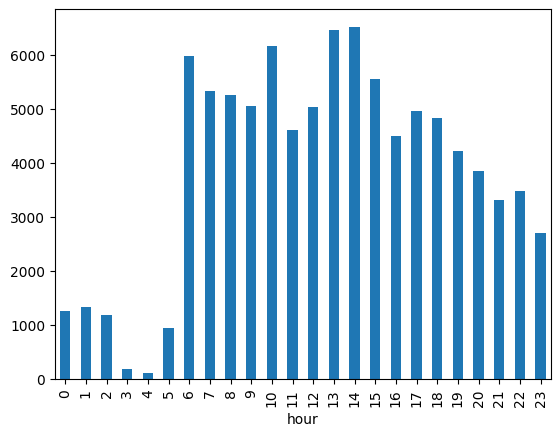

In [128]:
# Volume par heure
df_hist.groupby('hour').size().plot(kind='bar')

# Volume par jour de semaine
df_hist.groupby('weekday_name').size()

# Saisonnalité mensuelle
df_hist.groupby('month').size()

# Tendance dans le temps (resample)
df_hist.set_index('Date and Time').resample('ME').size()   # par jour
df_hist.set_index('Date and Time').resample('QE').size()   # par semaine
df_hist.set_index('Date and Time').resample('YE').size()   # par mois

In [129]:
df_hist['Aircraft Type'].value_counts()

Aircraft Type
C    82957
D     4117
B     3883
E     1975
A       10
Name: count, dtype: int64

In [130]:
df_hist['Arrival / Departure' ].value_counts()

Arrival / Departure
D    46480
A    46462
Name: count, dtype: int64

In [131]:
df_hist['Passenger/Cargo'].value_counts()

Passenger/Cargo
Commercial     88605
Cargo           3178
Positioning     1159
Name: count, dtype: int64

In [132]:
df_hist['Origin / Destination'].value_counts(normalize=True)


Origin / Destination
LHR    0.056325
DUB    0.055680
AMS    0.036614
STN    0.036485
CDG    0.029965
         ...   
JED    0.000011
RDU    0.000011
XFW    0.000011
BGR    0.000011
VIT    0.000011
Name: proportion, Length: 222, dtype: float64

# Feature engineering

In [133]:
df_hist.isna().sum()

Date and Time           0
Passenger/Cargo         0
Flight ID               0
Turnaround Flight ID    0
Arrival / Departure     0
Aircraft Type           0
Airline                 0
Origin / Destination    0
hour                    0
minute                  0
weekday                 0
weekday_name            0
day                     0
month                   0
month_name              0
quarter                 0
year                    0
week                    0
is_weekend              0
hour_sin                0
hour_cos                0
month_sin               0
month_cos               0
weekday_sin             0
weekday_cos             0
dtype: int64

Je veux construire un modele qui peut s'entrainer sur ces données pour que dans le futrure, quand y'a un avion
qui arrive, et que sur le schedule y'a des vols de départs, dans 3h, 1H, 30 min....., le modele va attribuer des 
scores de probabilité de correspondance entre les vols d'arrivées et les vols de départs, en se basant sur les 
caractéristiques des vols et les données historiques de correspondances réussies pour a la fin predire cet avion qui est arrivé va partir dans quel vol futur.


In [134]:
df_hist.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination,hour,minute,weekday,weekday_name,day,month,month_name,quarter,year,week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC,0,0,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN,0,5,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO,0,15,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,0,30,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN,1,10,3,Thursday,1,6,June,2,2023,22,0,0.258819,0.965926,1.224647e-16,-1.0,0.433884,-0.900969


Faut entrainer le modele sur des liens, donc faut identifier les vols qui ont les memes id

In [167]:
# 1. SPLIT EN PREMIER sur df_hist
df_train_raw, df_test_raw = train_test_split(df_hist, test_size=0.2, random_state=42)

# 2. ENSUITE merge séparément
df_arr_train = df_train_raw[df_train_raw['Arrival / Departure'] == 'A']
df_dep_train = df_train_raw[df_train_raw['Arrival / Departure'] == 'D']

df_arr_test = df_test_raw[df_test_raw['Arrival / Departure'] == 'A']
df_dep_test = df_test_raw[df_test_raw['Arrival / Departure'] == 'D']

# 3. Merge train
df_train = df_arr_train.merge(
    df_dep_train,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    suffixes=('_arr', '_dep')
)

# 4. Merge test
df_test = df_arr_test.merge(
    df_dep_test,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    suffixes=('_arr', '_dep')
)

In [168]:
df_train.columns

Index(['Date and Time_arr', 'Passenger/Cargo_arr', 'Flight ID_arr',
       'Turnaround Flight ID_arr', 'Arrival / Departure_arr',
       'Aircraft Type_arr', 'Airline_arr', 'Origin / Destination_arr',
       'hour_arr', 'minute_arr', 'weekday_arr', 'weekday_name_arr', 'day_arr',
       'month_arr', 'month_name_arr', 'quarter_arr', 'year_arr', 'week_arr',
       'is_weekend_arr', 'hour_sin_arr', 'hour_cos_arr', 'month_sin_arr',
       'month_cos_arr', 'weekday_sin_arr', 'weekday_cos_arr',
       'Date and Time_dep', 'Passenger/Cargo_dep', 'Flight ID_dep',
       'Turnaround Flight ID_dep', 'Arrival / Departure_dep',
       'Aircraft Type_dep', 'Airline_dep', 'Origin / Destination_dep',
       'hour_dep', 'minute_dep', 'weekday_dep', 'weekday_name_dep', 'day_dep',
       'month_dep', 'month_name_dep', 'quarter_dep', 'year_dep', 'week_dep',
       'is_weekend_dep', 'hour_sin_dep', 'hour_cos_dep', 'month_sin_dep',
       'month_cos_dep', 'weekday_sin_dep', 'weekday_cos_dep'],
      dtype='

In [169]:
# display all columns
pd.set_option('display.max_columns', None)
df_train.head()

,Date and Time_arr,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,Arrival / Departure_arr,Aircraft Type_arr,Airline_arr,Origin / Destination_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Date and Time_dep,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,Arrival / Departure_dep,Aircraft Type_dep,Airline_dep,Origin / Destination_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep
0,2023-06-21 11:55:00,Commercial,2662184,2662198,A,C,XQ,AYT,11,55,2,Wednesday,21,6,June,2,2023,25,0,2.588190e-01,-0.965926,1.224647e-16,-1.000000,0.974928,-0.222521,2023-06-21 12:45:00,Commercial,2662198,2662184,D,C,XQ,AYT,12,45,2,Wednesday,21,6,June,2,2023,25,0,1.224647e-16,-1.000000e+00,1.224647e-16,-1.000000,0.974928,-0.222521
1,2025-07-17 12:40:00,Commercial,3150757,3150783,A,C,KL,AMS,12,40,3,Thursday,17,7,July,3,2025,29,0,1.224647e-16,-1.000000,-5.000000e-01,-0.866025,0.433884,-0.900969,2025-07-17 13:25:00,Commercial,3150783,3150757,D,C,KL,AMS,13,25,3,Thursday,17,7,July,3,2025,29,0,-2.588190e-01,-9.659258e-01,-5.000000e-01,-0.866025,0.433884,-0.900969
2,2023-08-26 14:10:00,Commercial,2682947,2721061,A,C,FR,PMI,14,10,5,Saturday,26,8,August,3,2023,34,1,-5.000000e-01,-0.866025,-8.660254e-01,-0.500000,-0.974928,-0.222521,2023-08-26 15:35:00,Commercial,2721061,2682947,D,C,FR,NTE,15,35,5,Saturday,26,8,August,3,2023,34,1,-7.071068e-01,-7.071068e-01,-8.660254e-01,-0.500000,-0.974928,-0.222521
3,2024-07-07 09:05:00,Commercial,2973524,2973525,A,C,EI,DUB,9,5,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-0.707107,-5.000000e-01,-0.866025,-0.781831,0.623490,2024-07-07 09:35:00,Commercial,2973525,2973524,D,C,EI,DUB,9,35,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-7.071068e-01,-5.000000e-01,-0.866025,-0.781831,0.623490
4,2025-07-27 17:40:00,Commercial,3198389,3198390,A,C,EW,DUS,17,40,6,Sunday,27,7,July,3,2025,30,1,-9.659258e-01,-0.258819,-5.000000e-01,-0.866025,-0.781831,0.623490,2025-07-27 18:20:00,Commercial,3198390,3198389,D,C,EW,DUS,18,20,6,Sunday,27,7,July,3,2025,30,1,-1.000000e+00,-1.836970e-16,-5.000000e-01,-0.866025,-0.781831,0.623490


## Create Turnaround Time (Hours)

In [170]:
def add_turnaround(df):
    df['Turnaround Time'] = (
        df['Date and Time_dep'] - df['Date and Time_arr']
    ).dt.total_seconds() / 3600
    return df

df_train = add_turnaround(df_train)
df_test = add_turnaround(df_test)

In [171]:
df_train['Turnaround Time'] = (
    df_train['Date and Time_dep'] - df_train['Date and Time_arr']
).dt.total_seconds() / 3600

df_test['Turnaround Time'] = (
    df_test['Date and Time_dep'] - df_test['Date and Time_arr']
).dt.total_seconds() / 3600

In [172]:
df_train['Turnaround Time'].describe()

count    29671.000000
mean         2.997818
std          6.177430
min        -11.250000
25%          0.583333
50%          0.833333
75%          2.833333
max        237.583333
Name: Turnaround Time, dtype: float64

In [173]:
df_test['Turnaround Time'].describe()

count    1858.000000
mean        3.051399
std         6.080151
min        -6.250000
25%         0.583333
50%         0.833333
75%         3.291667
max       140.083333
Name: Turnaround Time, dtype: float64

### Encodage de Cargo/Passenger avec one hot encoding

In [176]:
df_train['Passenger/Cargo_arr'].value_counts(normalize=True)*100 ,df_test['Passenger/Cargo_arr'].value_counts(normalize=True)*100


(Passenger/Cargo_arr
 Commercial     95.409659
 Cargo           3.491625
 Positioning     1.098716
 Name: proportion, dtype: float64,
 Passenger/Cargo_arr
 Commercial     95.317546
 Cargo           4.036598
 Positioning     0.645856
 Name: proportion, dtype: float64)

Cargo and Positioning flights represent less than 5% of the dataset combined, which could introduce bias in our model. To address this, we create a dummy equal to 1 if the flight is Commercial and 0 otherwise

In [177]:
# Train
df_train['is_commercial_arr'] = (df_train['Passenger/Cargo_arr'] == 'Commercial').astype(int)
df_train['is_commercial_dep'] = (df_train['Passenger/Cargo_dep'] == 'Commercial').astype(int)

# Test
df_test['is_commercial_arr'] = (df_test['Passenger/Cargo_arr'] == 'Commercial').astype(int)
df_test['is_commercial_dep'] = (df_test['Passenger/Cargo_dep'] == 'Commercial').astype(int)


for Arrival / Departure, after the merge the colmuns are either D or A, so we can keep only one

In [178]:
# Train
df_train.drop(columns=['Arrival / Departure_arr', 'Arrival / Departure_dep'], inplace=True)

# Test
df_test.drop(columns=['Arrival / Departure_arr', 'Arrival / Departure_dep'], inplace=True)

In [179]:
# Train
df_train.drop(columns=['Aircraft Type_dep'], inplace=True)
df_train.rename(columns={'Aircraft Type_arr': 'Aircraft Type'}, inplace=True)

# Test
df_test.drop(columns=['Aircraft Type_dep'], inplace=True)
df_test.rename(columns={'Aircraft Type_arr': 'Aircraft Type'}, inplace=True)

In [180]:
df_train['Aircraft Type'].value_counts(), df_test['Aircraft Type'].value_counts()

(Aircraft Type
 C    26524
 D     1284
 B     1232
 E      629
 A        2
 Name: count, dtype: int64,
 Aircraft Type
 C    1667
 B      86
 D      72
 E      33
 Name: count, dtype: int64)

## Aircraft Categories

- **Category A**: less than 169 km/h (91 knots) indicated airspeed (IAS)  
- **Category B**: 169 km/h (91 knots) or more but less than 224 km/h (121 knots) IAS  
- **Category C**: 224 km/h (121 knots) or more but less than 261 km/h (141 knots) IAS  
- **Category D**: 261 km/h (141 knots) or more but less than 307 km/h (166 knots) IAS  
- **Category E**: 307 km/h (166 knots) or more but less than 391 km/h (211 knots) IAS  
- **Category H**: Helicopters

WIKIPEDIA

SO it's in an order, from lower to higher , wen can map the categories from 1 to 5

In [181]:
size_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}

# Train
df_train['Aircraft Size'] = df_train['Aircraft Type'].map(size_map)
df_train.drop(columns=['Aircraft Type'], inplace=True)

# Test
df_test['Aircraft Size'] = df_test['Aircraft Type'].map(size_map)
df_test.drop(columns=['Aircraft Type'], inplace=True)

## Origin / Destination
#### Creating pairs from departure to arrival, to see special patterns in turnaround when there is specific pairs

In [182]:
# Paire de routes arr → dep
df_train['route_pair'] = df_train['Origin / Destination_arr'] + '_' + df_train['Origin / Destination_dep']
df_test['route_pair'] = df_test['Origin / Destination_arr'] + '_' + df_test['Origin / Destination_dep']

# Frequency encoding — fit sur train seulement
freq_route = df_train['route_pair'].value_counts(normalize=True) * 100

# Transform train et test
df_train['route_pair_freq'] = df_train['route_pair'].map(freq_route)
df_test['route_pair_freq'] = df_test['route_pair'].map(freq_route).fillna(0)

# Drop
df_train.drop(columns=['route_pair', 'Origin / Destination_arr', 'Origin / Destination_dep'], inplace=True)
df_test.drop(columns=['route_pair', 'Origin / Destination_arr', 'Origin / Destination_dep'], inplace=True)

## Airline

In [183]:
(df_train['Airline_arr']==df_train['Airline_dep']).all()

np.False_

In [185]:
(df_train['Airline_arr'] != df_train['Airline_dep']).sum()

np.int64(98)

In [186]:
df_train[df_train['Airline_arr'] != df_train['Airline_dep']][['Airline_arr', 'Airline_dep']].value_counts()

Airline_arr  Airline_dep
FR           RK             43
RK           FR             40
FX           3V              3
NPT          7J              3
SWN          NPT             2
7J           NPT             2
FX           ABR             1
3V           FX              1
NPT          SWN             1
QY           D0              1
U2           EC              1
Name: count, dtype: int64

## Mapper les DEP_ARR et calculer leurs frequences

In [187]:
# Paire de compagnies
df_train['airline_pair'] = df_train['Airline_arr'] + '_' + df_train['Airline_dep']
df_test['airline_pair'] = df_test['Airline_arr'] + '_' + df_test['Airline_dep']

# Frequency encoding — fit sur train seulement
freq_pair = df_train['airline_pair'].value_counts(normalize=True)

# Transform train et test
df_train['airline_pair_freq'] = df_train['airline_pair'].map(freq_pair)
df_test['airline_pair_freq'] = df_test['airline_pair'].map(freq_pair).fillna(0)

# Drop
df_train.drop(columns=['Airline_arr', 'Airline_dep', 'airline_pair'], inplace=True)
df_test.drop(columns=['Airline_arr', 'Airline_dep', 'airline_pair'], inplace=True)

In [189]:
df_train['route_pair_freq'].describe(), df_train['airline_pair_freq'].describe()

(count    29671.000000
 mean         1.045787
 std          1.597619
 min          0.003370
 25%          0.037073
 50%          0.212329
 75%          1.482929
 max          5.537393
 Name: route_pair_freq, dtype: float64,
 count    29671.000000
 mean         0.110232
 std          0.083603
 min          0.000034
 25%          0.024603
 50%          0.092649
 75%          0.204442
 max          0.206936
 Name: airline_pair_freq, dtype: float64)

In [190]:
df_train.head()

,Date and Time_arr,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Date and Time_dep,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair_freq,airline_pair_freq
0,2023-06-21 11:55:00,Commercial,2662184,2662198,11,55,2,Wednesday,21,6,June,2,2023,25,0,2.588190e-01,-0.965926,1.224647e-16,-1.000000,0.974928,-0.222521,2023-06-21 12:45:00,Commercial,2662198,2662184,12,45,2,Wednesday,21,6,June,2,2023,25,0,1.224647e-16,-1.000000e+00,1.224647e-16,-1.000000,0.974928,-0.222521,0.833333,1,1,3,0.417916,0.004752
1,2025-07-17 12:40:00,Commercial,3150757,3150783,12,40,3,Thursday,17,7,July,3,2025,29,0,1.224647e-16,-1.000000,-5.000000e-01,-0.866025,0.433884,-0.900969,2025-07-17 13:25:00,Commercial,3150783,3150757,13,25,3,Thursday,17,7,July,3,2025,29,0,-2.588190e-01,-9.659258e-01,-5.000000e-01,-0.866025,0.433884,-0.900969,0.750000,1,1,3,2.996192,0.024603
2,2023-08-26 14:10:00,Commercial,2682947,2721061,14,10,5,Saturday,26,8,August,3,2023,34,1,-5.000000e-01,-0.866025,-8.660254e-01,-0.500000,-0.974928,-0.222521,2023-08-26 15:35:00,Commercial,2721061,2682947,15,35,5,Saturday,26,8,August,3,2023,34,1,-7.071068e-01,-7.071068e-01,-8.660254e-01,-0.500000,-0.974928,-0.222521,1.416667,1,1,3,0.003370,0.204442
3,2024-07-07 09:05:00,Commercial,2973524,2973525,9,5,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-0.707107,-5.000000e-01,-0.866025,-0.781831,0.623490,2024-07-07 09:35:00,Commercial,2973525,2973524,9,35,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-7.071068e-01,-5.000000e-01,-0.866025,-0.781831,0.623490,0.500000,1,1,3,4.799299,0.051532
4,2025-07-27 17:40:00,Commercial,3198389,3198390,17,40,6,Sunday,27,7,July,3,2025,30,1,-9.659258e-01,-0.258819,-5.000000e-01,-0.866025,-0.781831,0.623490,2025-07-27 18:20:00,Commercial,3198390,3198389,18,20,6,Sunday,27,7,July,3,2025,30,1,-1.000000e+00,-1.836970e-16,-5.000000e-01,-0.866025,-0.781831,0.623490,0.666667,1,1,3,0.407806,0.011088


### Working on date and time

In [191]:
for df in [df_train, df_test]:
    df['hour_arr'] = df['Date and Time_arr'].dt.hour
    df['hour_dep'] = df['Date and Time_dep'].dt.hour
    df['day_of_week'] = df['Date and Time_arr'].dt.dayofweek
    df['month'] = df['Date and Time_arr'].dt.month
    df.drop(columns=['Date and Time_arr', 'Date and Time_dep'], inplace=True)

In [192]:
df_train.head()

,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair_freq,airline_pair_freq,day_of_week,month
0,Commercial,2662184,2662198,11,55,2,Wednesday,21,6,June,2,2023,25,0,2.588190e-01,-0.965926,1.224647e-16,-1.000000,0.974928,-0.222521,Commercial,2662198,2662184,12,45,2,Wednesday,21,6,June,2,2023,25,0,1.224647e-16,-1.000000e+00,1.224647e-16,-1.000000,0.974928,-0.222521,0.833333,1,1,3,0.417916,0.004752,2,6
1,Commercial,3150757,3150783,12,40,3,Thursday,17,7,July,3,2025,29,0,1.224647e-16,-1.000000,-5.000000e-01,-0.866025,0.433884,-0.900969,Commercial,3150783,3150757,13,25,3,Thursday,17,7,July,3,2025,29,0,-2.588190e-01,-9.659258e-01,-5.000000e-01,-0.866025,0.433884,-0.900969,0.750000,1,1,3,2.996192,0.024603,3,7
2,Commercial,2682947,2721061,14,10,5,Saturday,26,8,August,3,2023,34,1,-5.000000e-01,-0.866025,-8.660254e-01,-0.500000,-0.974928,-0.222521,Commercial,2721061,2682947,15,35,5,Saturday,26,8,August,3,2023,34,1,-7.071068e-01,-7.071068e-01,-8.660254e-01,-0.500000,-0.974928,-0.222521,1.416667,1,1,3,0.003370,0.204442,5,8
3,Commercial,2973524,2973525,9,5,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-0.707107,-5.000000e-01,-0.866025,-0.781831,0.623490,Commercial,2973525,2973524,9,35,6,Sunday,7,7,July,3,2024,27,1,7.071068e-01,-7.071068e-01,-5.000000e-01,-0.866025,-0.781831,0.623490,0.500000,1,1,3,4.799299,0.051532,6,7
4,Commercial,3198389,3198390,17,40,6,Sunday,27,7,July,3,2025,30,1,-9.659258e-01,-0.258819,-5.000000e-01,-0.866025,-0.781831,0.623490,Commercial,3198390,3198389,18,20,6,Sunday,27,7,July,3,2025,30,1,-1.000000e+00,-1.836970e-16,-5.000000e-01,-0.866025,-0.781831,0.623490,0.666667,1,1,3,0.407806,0.011088,6,7


In [193]:
cols = [
    'Turnaround Time',
    'is_commercial_arr',
    'is_commercial_dep',
    'Aircraft Size',
    'route_pair_freq',
    'airline_pair_freq',
    'hour_arr',
    'hour_dep',
    'day_of_week',
    'month'
]

df_train_final = df_train[cols].copy()
df_test_final = df_test[cols].copy()


In [194]:
df_train_final.head()

,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair_freq,airline_pair_freq,hour_arr,hour_dep,day_of_week,month
0,0.833333,1,1,3,0.417916,0.004752,11,12,2,6
1,0.750000,1,1,3,2.996192,0.024603,12,13,3,7
2,1.416667,1,1,3,0.003370,0.204442,14,15,5,8
3,0.500000,1,1,3,4.799299,0.051532,9,9,6,7
4,0.666667,1,1,3,0.407806,0.011088,17,18,6,7


## Handle Time

Text(0.5, 1.0, 'Distribution des heures de départ')

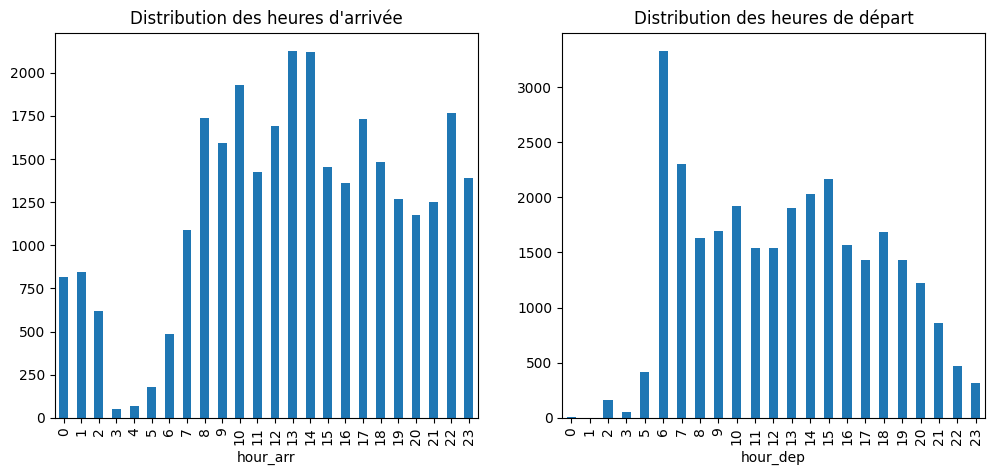

In [195]:
# faire un bar plot sur les heures d'arrivée et de départ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_train_final['hour_arr'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des heures d\'arrivée')
plt.subplot(1, 2, 2)
df_train_final['hour_dep'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des heures de départ')


In [196]:
df_train_final.isnull().sum(), df_test_final.isnull().sum()

(Turnaround Time      0
 is_commercial_arr    0
 is_commercial_dep    0
 Aircraft Size        0
 route_pair_freq      0
 airline_pair_freq    0
 hour_arr             0
 hour_dep             0
 day_of_week          0
 month                0
 dtype: int64,
 Turnaround Time      0
 is_commercial_arr    0
 is_commercial_dep    0
 Aircraft Size        0
 route_pair_freq      0
 airline_pair_freq    0
 hour_arr             0
 hour_dep             0
 day_of_week          0
 month                0
 dtype: int64)

#### The dataset is initially Ready for modeling